<img src="rupixen-Q59HmzK38eQ-unsplash.jpg" alt="Someone is trying to purchase a produce online" width="500"/>

Online shopping decisions rely on how consumers engage with online store content. You work for a new startup company that has just launched a new online shopping website. The marketing team asks you, a new data scientist, to review a dataset of online shoppers' purchasing intentions gathered over the last year. Specifically, the team wants you to generate some insights into customer browsing behaviors in November and December, the busiest months for shoppers. You have decided to identify two groups of customers: those with a low purchase rate and returning customers. After identifying these groups, you want to determine the probability that any of these customers will make a purchase in a new marketing campaign to help gauge potential success for next year's sales.

### Data description:

You are given an `online_shopping_session_data.csv` that contains several columns about each shopping session. Each shopping session corresponded to a single user. 

|Column|Description|
|--------|-----------|
|`SessionID`|unique session ID|
|`Administrative`|number of pages visited related to the customer account|
|`Administrative_Duration`|total amount of time spent (in seconds) on administrative pages|
|`Informational`|number of pages visited related to the website and the company|
|`Informational_Duration`|total amount of time spent (in seconds) on informational pages|
|`ProductRelated`|number of pages visited related to available products|
|`ProductRelated_Duration`|total amount of time spent (in seconds) on product-related pages|
|`BounceRates`|average bounce rate of pages visited by the customer|
|`ExitRates`|average exit rate of pages visited by the customer|
|`PageValues`|average page value of pages visited by the customer|
|`SpecialDay`|closeness of the site visiting time to a specific special day|
|`Weekend`|indicator whether the session is on a weekend|
|`Month`|month of the session date|
|`CustomerType`|customer type|
|`Purchase`|class label whether the customer make a purchase|


### The marketing team asked you to analyze the behavior of online customers during November and December, the busiest months for shoppers.

#### 1. What are the purchase rates for online shopping sessions by customer type for November and December? Store the result in a dictionary called purchase_rates in the format below using the exact names for keys.
#### purchase_rates = {"Returning_Customer": 0.254, "New_Customer": 0.276}

#### 2. What is the strongest correlation in total time spent among page types by returning customers in November and December? Store the result in a dictionary called top_correlation in the format below using the exact names for keys.
#### top_correlation = {"pair": (x_duration, y_duration), "correlation": 0.345}

#### 3. A new campaign for the returning customers will boost the purchase rate by 15%. What is the likelihood of achieving at least 100 sales out of 500 online shopping sessions for the returning customers? Store the result in a variable called prob_at_least_100_sales. Optional: plot a binomial probability distribution chart to visualize your chances.

In [210]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom

# Load and view the data
shopping_data = pd.read_csv("online_shopping_session_data.csv")
shopping_data.head()

,SessionID,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Weekend,Month,CustomerType,Purchase
0,1,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,False,Feb,Returning_Customer,0.0
1,2,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,False,Feb,Returning_Customer,0.0
2,3,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,False,Feb,Returning_Customer,0.0
3,4,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,False,Feb,Returning_Customer,0.0
4,5,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,True,Feb,Returning_Customer,0.0


#### Question 1

In [211]:
shopping_data_nov_dec = shopping_data[(shopping_data['Month'] == 'Nov') | (shopping_data['Month'] == 'Dec')]

print(shopping_data_nov_dec.head())

      SessionID  Administrative  Administrative_Duration  Informational  \
5463       5464               1                     39.2              2   
5464       5465               3                     89.6              0   
5467       5468               4                    204.2              0   
5479       5480               0                      0.0              0   
5494       5495               0                      0.0              0   

      Informational_Duration  ProductRelated  ProductRelated_Duration  \
5463                   120.8               7                80.500000   
5464                     0.0              57              1721.906667   
5467                     0.0              31               652.376667   
5479                     0.0              13               710.066667   
5494                     0.0              24               968.692424   

      BounceRates  ExitRates  PageValues  SpecialDay  Weekend Month  \
5463     0.000000   0.010000    0.00000

In [212]:
print(shopping_data_nov_dec['Purchase'].value_counts())

Purchase
0.0    3523
1.0     927
Name: count, dtype: int64


In [213]:
purchase_rate_series = shopping_data_nov_dec.groupby('CustomerType')['Purchase'].mean()

purchase_rate = purchase_rate_series.to_dict()

print(purchase_rate)

{'New_Customer': 0.2733516483516483, 'Returning_Customer': 0.1955937667920473}


#### Question 2

In [214]:
filt_returning = shopping_data_nov_dec[shopping_data_nov_dec['CustomerType'] == 'Returning_Customer']

print(filt_returning)

       SessionID  Administrative  Administrative_Duration  Informational  \
5464        5465               3                89.600000              0   
5467        5468               4               204.200000              0   
5479        5480               0                 0.000000              0   
5494        5495               0                 0.000000              0   
5497        5498              13              1013.056909              2   
...          ...             ...                      ...            ...   
12049      12050               6               141.916667              2   
12050      12051               6               183.250000              2   
12051      12052              10               297.833333             12   
12052      12053               0                 0.000000              2   
12053      12054               7                97.000000              3   

       Informational_Duration  ProductRelated  ProductRelated_Duration  \
5464         

In [215]:
print(filt_returning['Administrative_Duration'].corr(filt_returning['Informational_Duration']))

0.25810799265723017


In [216]:
print(filt_returning['Administrative_Duration'].corr(filt_returning['ProductRelated_Duration']))

0.4168929388342279


In [217]:
print(filt_returning['Informational_Duration'].corr(filt_returning['ProductRelated_Duration']))

0.3665511197116854


#### Question 3

In [218]:
ret_rate = purchase_rate['Returning_Customer']

print(ret_rate)

0.1955937667920473


In [219]:
p_new = ret_rate * 1.15
n = 500

prob_at_least_100_sales = binom.sf(99, n= 500, p = p_new)

print(prob_at_least_100_sales)

0.9190464150313488


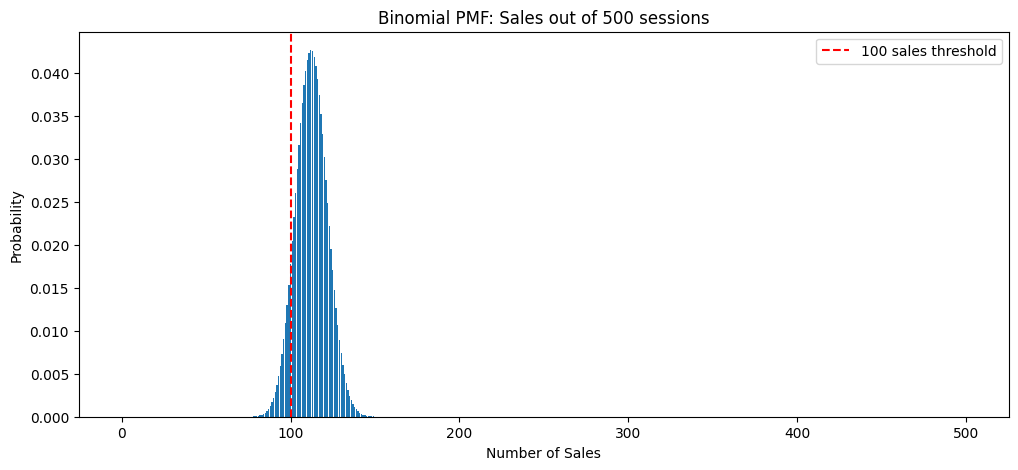

In [220]:
x = np.arange(0, n+1)
pmf = binom.pmf(x, n=n, p=p_new)

plt.figure(figsize=(12, 5))
plt.bar(x, pmf)
plt.axvline(100, linestyle="--", label="100 sales threshold", color = 'red')
plt.title("Binomial PMF: Sales out of 500 sessions")
plt.xlabel("Number of Sales")
plt.ylabel("Probability")
plt.legend()
plt.show()